Device: cuda


100%|██████████| 170M/170M [00:04<00:00, 35.3MB/s]


Epoch: 1 LossD: 0.12004119157791138 LossG: 4.095680236816406
Epoch: 2 LossD: 1.3105602264404297 LossG: 8.257314682006836
Epoch: 3 LossD: 0.6054501533508301 LossG: 1.5309038162231445
Generated Artistic Images


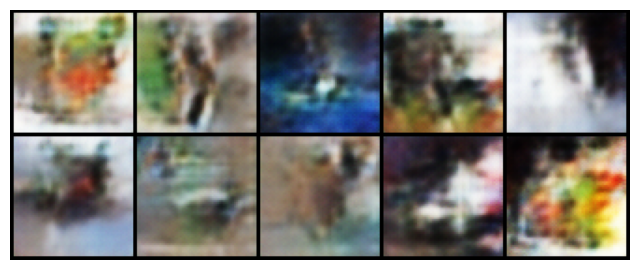

Latent Space Interpolation


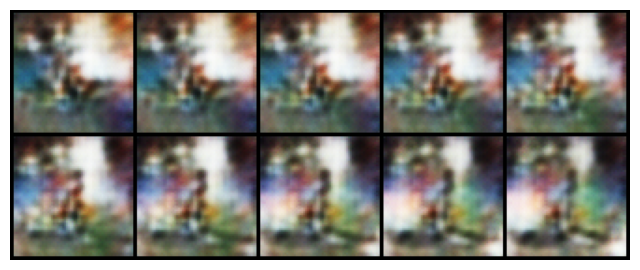

In [1]:
# Install libraries
!pip install torch torchvision matplotlib

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ---------------------------
# 1. DATA PREPARATION
# ---------------------------

transform = transforms.Compose([
    transforms.Resize(64),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=64,
    shuffle=True
)

latent_dim = 100

# ---------------------------
# 2. GENERATOR
# ---------------------------

class Generator(nn.Module):

    def __init__(self):
        super().__init__()

        self.main = nn.Sequential(

            nn.ConvTranspose2d(latent_dim,512,4,1,0,bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            nn.ConvTranspose2d(512,256,4,2,1,bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256,128,4,2,1,bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128,64,4,2,1,bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64,3,4,2,1,bias=False),
            nn.Tanh()
        )

    def forward(self,x):
        return self.main(x)

# ---------------------------
# 3. DISCRIMINATOR
# ---------------------------

class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.main = nn.Sequential(

            nn.Conv2d(3,64,4,2,1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64,128,4,2,1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128,256,4,2,1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Conv2d(256,512,4,2,1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),

            nn.Conv2d(512,1,4,1,0),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.main(x).view(-1)

generator = Generator().to(device)
discriminator = Discriminator().to(device)

# ---------------------------
# 4. TRAINING SETUP
# ---------------------------

criterion = nn.BCELoss()

optimizerG = torch.optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5,0.999))
optimizerD = torch.optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5,0.999))

epochs = 3

# ---------------------------
# 5. TRAIN GAN
# ---------------------------

for epoch in range(epochs):

    for real,_ in dataloader:

        real = real.to(device)
        batch_size = real.size(0)

        real_labels = torch.ones(batch_size).to(device)
        fake_labels = torch.zeros(batch_size).to(device)

        # ---- Train Discriminator ----

        optimizerD.zero_grad()

        outputs = discriminator(real)
        loss_real = criterion(outputs, real_labels)

        noise = torch.randn(batch_size,latent_dim,1,1).to(device)
        fake = generator(noise)

        outputs = discriminator(fake.detach())
        loss_fake = criterion(outputs, fake_labels)

        lossD = loss_real + loss_fake
        lossD.backward()

        optimizerD.step()

        # ---- Train Generator ----

        optimizerG.zero_grad()

        outputs = discriminator(fake)
        lossG = criterion(outputs, real_labels)

        lossG.backward()
        optimizerG.step()

    print("Epoch:",epoch+1,"LossD:",lossD.item(),"LossG:",lossG.item())

# ---------------------------
# 6. SHOW IMAGE FUNCTION
# ---------------------------

def show_images(images):

    images = images/2 + 0.5
    grid = torchvision.utils.make_grid(images, nrow=5)

    plt.figure(figsize=(8,8))
    plt.imshow(np.transpose(grid,(1,2,0)))
    plt.axis("off")
    plt.show()

# ---------------------------
# 7. GENERATE ARTISTIC IMAGES
# ---------------------------

noise = torch.randn(10,latent_dim,1,1).to(device)

generated_images = generator(noise).detach().cpu()

print("Generated Artistic Images")
show_images(generated_images)

# ---------------------------
# 8. LATENT SPACE INTERPOLATION
# ---------------------------

z1 = torch.randn(1,latent_dim,1,1).to(device)
z2 = torch.randn(1,latent_dim,1,1).to(device)

interpolated = []

for alpha in np.linspace(0,1,10):

    z = (1-alpha)*z1 + alpha*z2
    img = generator(z).detach().cpu()
    interpolated.append(img)

interpolated = torch.cat(interpolated)

print("Latent Space Interpolation")
show_images(interpolated)